In [1]:
import pandas as pd
import numpy as np
from plotly import tools
from plotly.offline import iplot
import plotly.graph_objects as go
import warnings
warnings.simplefilter('ignore')
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
lsls=[]
lstb=[]

def length(x):
    df=pd.DataFrame(x,columns=['x','y','z'])
    disc_dst=np.sqrt((df['x'].diff()**2) + (df['y'].diff()**2) + (df['z'].diff()**2))
    lngth=disc_dst.sum()
    return lngth

def plot_curvature(siml,color,file_name):
    def curvature(df):
        x = df['X'].values
        y = df['Y'].values
        z = df['Z'].values
        dx = np.gradient(x)
        dy = np.gradient(y)
        dz = np.gradient(z)
        ddx = np.gradient(dx)
        ddy = np.gradient(dy)
        ddz = np.gradient(dz)
        cross = np.cross(np.vstack((dx,dy,dz)).T, np.vstack((ddx,ddy,ddz)).T)
        cross_norm = np.linalg.norm(cross, axis=1)
        first_norm = np.linalg.norm(np.vstack((dx,dy,dz)).T, axis=1)
        curvature = cross_norm / (first_norm**3)
        return curvature
    fig2=go.Scatter(x=[i for i in range(1,101,1)], y=curvature(siml),mode='lines',name=file_name,line=dict(color=color,width=3))
        # fig3=go.Scatter(x=[i for i in range(1,101,1)], y=curvature(prt),mode='lines',name='Prototype',line=dict(color='dodgerblue',width=3))
    return fig2

def myscatter(doe_df1,posit):

    cols = [c for c in doe_df1.columns if c not in ["case"]]
    inputs = [c for c in cols if c != "deviation"]

    n = len(inputs)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=n,
        figsize=(12,7), constrained_layout=True, sharex='col',sharey='row'
    )

    # Colormap
    norm = mpl.colors.Normalize(
        vmin=doe_df1["deviation"].min(),
        vmax=doe_df1["deviation"].max()
    )

    cmap = plt.cm.viridis

    for i, yi in enumerate(inputs):
        for j, xj in enumerate(inputs):

            ax = axes[i, j]
            if j >= i:
                ax.remove()
                continue

            sc = ax.scatter(
                doe_df1[xj],
                doe_df1[yi],
                c=doe_df1["deviation"],
                cmap=cmap,
                norm=norm,
                s=30,
                alpha=0.8
            )
            if i == n - 1:
                ax.set_xlabel(xj)
            if j == 0:
                ax.set_ylabel(yi)
            ax.ticklabel_format(style='sci', axis='both', scilimits=(0,2))
            ax.xaxis.get_offset_text().set_size(5)
            ax.yaxis.get_offset_text().set_size(5)
    cax = fig.add_axes([0.77, 0.65,0.02,0.2])
    cb = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cax
    )
    fig.text(0.4,0.8,f"Wiper Position {posit}", fontsize=20)
    cb.set_label("deviation")
    plt.subplots_adjust(wspace=0.05,hspace=0.05)
    plt.show()


In [2]:
#| label: w1-main

df=pd.read_csv('../../data/2001/w1.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[:25]
prt=df.iloc[10:,2:].reset_index(drop=True).values
p0=df.iloc[5,2:].values.astype(float)
p1=df.iloc[6,2:].values.astype(float)
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=prt[:,0],y=prt[:,1],z=prt[:,2],mode='lines',name='Prototype',line=dict(color='black',width=6)))
fig.add_trace(go.Scatter3d(x=[p0[0]],y=[p0[1]],z=[p0[2]],mode='markers',name='P0',marker=dict(size=5,color='red')))
fig.add_trace(go.Scatter3d(x=[p1[0]],y=[p1[1]],z=[p1[2]],mode='markers',name='P1',marker=dict(size=5,color='red')))
fig.add_trace(go.Cone(x=[p0[0]],y=[p0[1]],z=[p0[2]],u=[u0[0]],v=[u0[1]],w=[u0[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P0',showlegend=False))
fig.add_trace(go.Cone(x=[p1[0]],y=[p1[1]],z=[p1[2]],u=[u1[0]],v=[u1[1]],w=[u1[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P1',showlegend=False))
a=pd.DataFrame(prt).iloc[50].values

param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
dash_map = {-10: "dot",-5: "dash",5: "longdash",10: "solid"}
for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w1_'+scenario+'.csv')
    spl3=spl3.values
    color=param_colors[param]
    dash=dash_map[lvl]
    fig.add_trace(go.Scatter3d(
        x=spl3[:,0],
        y=spl3[:,1],
        z=spl3[:,2],
        mode='lines',
        name=param,
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=6,dash=dash),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    ))

spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w1_baseline.csv').values
fig.add_trace(go.Scatter3d(
    x=spl3[:,0],
    y=spl3[:,1],
    z=spl3[:,2],
    mode='lines',
    name='Baseline',
    showlegend=True,
    line=dict(color='darkslategrey',width=6),
    customdata=np.tile(np.array(['Baseline',doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
    hovertemplate=f"Baseline<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
))

fig.update_layout(title='Simulated - W1 - OFAT',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),legend=dict(x=0.02,y=0.05,orientation='h',groupclick='togglegroup'),font=dict(size=15,family='Times New Roman'),autosize=False,height=550,width=600,margin=dict(l=20,r=20,t=40,b=20),showlegend=True)
fig.update_scenes(camera_projection_type='orthographic')

fig.show()

In [3]:
#| label: w2-main

df=pd.read_csv('../../data/2001/w2.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[25:50]
prt=df.iloc[10:,2:].reset_index(drop=True).values
p0=df.iloc[5,2:].values.astype(float)
p1=df.iloc[6,2:].values.astype(float)
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=prt[:,0],y=prt[:,1],z=prt[:,2],mode='lines',name='Prototype',line=dict(color='black',width=6)))
fig.add_trace(go.Scatter3d(x=[p0[0]],y=[p0[1]],z=[p0[2]],mode='markers',name='P0',marker=dict(size=5,color='red')))
fig.add_trace(go.Scatter3d(x=[p1[0]],y=[p1[1]],z=[p1[2]],mode='markers',name='P1',marker=dict(size=5,color='red')))
fig.add_trace(go.Cone(x=[p0[0]],y=[p0[1]],z=[p0[2]],u=[u0[0]],v=[u0[1]],w=[u0[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P0',showlegend=False))
fig.add_trace(go.Cone(x=[p1[0]],y=[p1[1]],z=[p1[2]],u=[u1[0]],v=[u1[1]],w=[u1[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P1',showlegend=False))
a=pd.DataFrame(prt).iloc[50].values

param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
dash_map = {-10: "dot",-5: "dash",5: "longdash",10: "solid"}
for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w2_'+scenario+'.csv')
    spl3=spl3.values
    color=param_colors[param]
    dash=dash_map[lvl]
    fig.add_trace(go.Scatter3d(
        x=spl3[:,0],
        y=spl3[:,1],
        z=spl3[:,2],
        mode='lines',
        name=param,
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=6,dash=dash),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    ))

spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w2_baseline.csv').values
fig.add_trace(go.Scatter3d(
    x=spl3[:,0],
    y=spl3[:,1],
    z=spl3[:,2],
    mode='lines',
    name='Baseline',
    showlegend=True,
    line=dict(color='darkslategrey',width=6),
    customdata=np.tile(np.array(['Baseline',doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
    hovertemplate=f"Baseline<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
))

fig.update_layout(title='Simulated - W2 - OFAT',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),legend=dict(x=0.02,y=0.05,orientation='h',groupclick='togglegroup'),font=dict(size=15,family='Times New Roman'),autosize=False,height=550,width=600,margin=dict(l=20,r=20,t=40,b=20),showlegend=True)
fig.update_scenes(camera_projection_type='orthographic')

fig.show()

In [4]:
#| label: w3-main

df=pd.read_csv('../../data/2001/w3.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[50:75]
prt=df.iloc[10:,2:].reset_index(drop=True).values
p0=df.iloc[5,2:].values.astype(float)
p1=df.iloc[6,2:].values.astype(float)
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=prt[:,0],y=prt[:,1],z=prt[:,2],mode='lines',name='Prototype',line=dict(color='black',width=6)))
fig.add_trace(go.Scatter3d(x=[p0[0]],y=[p0[1]],z=[p0[2]],mode='markers',name='P0',marker=dict(size=5,color='red')))
fig.add_trace(go.Scatter3d(x=[p1[0]],y=[p1[1]],z=[p1[2]],mode='markers',name='P1',marker=dict(size=5,color='red')))
fig.add_trace(go.Cone(x=[p0[0]],y=[p0[1]],z=[p0[2]],u=[u0[0]],v=[u0[1]],w=[u0[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P0',showlegend=False))
fig.add_trace(go.Cone(x=[p1[0]],y=[p1[1]],z=[p1[2]],u=[u1[0]],v=[u1[1]],w=[u1[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P1',showlegend=False))
a=pd.DataFrame(prt).iloc[50].values

param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
dash_map = {-10: "dot",-5: "dash",5: "longdash",10: "solid"}
for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w3_'+scenario+'.csv')
    spl3=spl3.values
    color=param_colors[param]
    dash=dash_map[lvl]
    fig.add_trace(go.Scatter3d(
        x=spl3[:,0],
        y=spl3[:,1],
        z=spl3[:,2],
        mode='lines',
        name=param,
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=6,dash=dash),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    ))

spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w3_baseline.csv').values
fig.add_trace(go.Scatter3d(
    x=spl3[:,0],
    y=spl3[:,1],
    z=spl3[:,2],
    mode='lines',
    name='Baseline',
    showlegend=True,
    line=dict(color='darkslategrey',width=6),
    customdata=np.tile(np.array(['Baseline',doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
    hovertemplate=f"Baseline<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
))

fig.update_layout(title='Simulated - W3 - OFAT',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),legend=dict(x=0.02,y=0.05,orientation='h',groupclick='togglegroup'),font=dict(size=15,family='Times New Roman'),autosize=False,height=550,width=600,margin=dict(l=20,r=20,t=40,b=20),showlegend=True)
fig.update_scenes(camera_projection_type='orthographic')

fig.show()

In [5]:
#| label: w4-main

df=pd.read_csv('../../data/2001/w4.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[75:100]
prt=df.iloc[10:,2:].reset_index(drop=True).values
p0=df.iloc[5,2:].values.astype(float)
p1=df.iloc[6,2:].values.astype(float)
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=prt[:,0],y=prt[:,1],z=prt[:,2],mode='lines',name='Prototype',line=dict(color='black',width=6)))
fig.add_trace(go.Scatter3d(x=[p0[0]],y=[p0[1]],z=[p0[2]],mode='markers',name='P0',marker=dict(size=5,color='red')))
fig.add_trace(go.Scatter3d(x=[p1[0]],y=[p1[1]],z=[p1[2]],mode='markers',name='P1',marker=dict(size=5,color='red')))
fig.add_trace(go.Cone(x=[p0[0]],y=[p0[1]],z=[p0[2]],u=[u0[0]],v=[u0[1]],w=[u0[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P0',showlegend=False))
fig.add_trace(go.Cone(x=[p1[0]],y=[p1[1]],z=[p1[2]],u=[u1[0]],v=[u1[1]],w=[u1[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P1',showlegend=False))
a=pd.DataFrame(prt).iloc[50].values

param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
dash_map = {-10: "dot",-5: "dash",5: "longdash",10: "solid"}
for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w4_'+scenario+'.csv')
    spl3=spl3.values
    color=param_colors[param]
    dash=dash_map[lvl]
    fig.add_trace(go.Scatter3d(
        x=spl3[:,0],
        y=spl3[:,1],
        z=spl3[:,2],
        mode='lines',
        name=param,
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=6,dash=dash),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    ))

spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w4_baseline.csv').values
fig.add_trace(go.Scatter3d(
    x=spl3[:,0],
    y=spl3[:,1],
    z=spl3[:,2],
    mode='lines',
    name='Baseline',
    showlegend=True,
    line=dict(color='darkslategrey',width=6),
    customdata=np.tile(np.array(['Baseline',doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
    hovertemplate=f"Baseline<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
))

fig.update_layout(title='Simulated - W4 - OFAT',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),legend=dict(x=0.02,y=0.05,orientation='h',groupclick='togglegroup'),font=dict(size=15,family='Times New Roman'),autosize=False,height=550,width=600,margin=dict(l=20,r=20,t=40,b=20),showlegend=True)
fig.update_scenes(camera_projection_type='orthographic')

fig.show()

In [6]:
#| label: w5-main

df=pd.read_csv('../../data/2001/w5.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[100:]
prt=df.iloc[10:,2:].reset_index(drop=True).values
p0=df.iloc[5,2:].values.astype(float)
p1=df.iloc[6,2:].values.astype(float)
u0=df.iloc[8,2:].values.astype(float)*df.iloc[2,1]
u1=df.iloc[9,2:].values.astype(float)*df.iloc[3,1]
fig=go.Figure()
fig.add_trace(go.Scatter3d(x=prt[:,0],y=prt[:,1],z=prt[:,2],mode='lines',name='Prototype',line=dict(color='black',width=6)))
fig.add_trace(go.Scatter3d(x=[p0[0]],y=[p0[1]],z=[p0[2]],mode='markers',name='P0',marker=dict(size=5,color='red')))
fig.add_trace(go.Scatter3d(x=[p1[0]],y=[p1[1]],z=[p1[2]],mode='markers',name='P1',marker=dict(size=5,color='red')))
fig.add_trace(go.Cone(x=[p0[0]],y=[p0[1]],z=[p0[2]],u=[u0[0]],v=[u0[1]],w=[u0[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P0',showlegend=False))
fig.add_trace(go.Cone(x=[p1[0]],y=[p1[1]],z=[p1[2]],u=[u1[0]],v=[u1[1]],w=[u1[2]],colorscale='RdPu',sizemode='absolute',sizeref=6,showscale=False,name='U@P1',showlegend=False))
a=pd.DataFrame(prt).iloc[50].values

param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
dash_map = {-10: "dot",-5: "dash",5: "longdash",10: "solid"}
for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w5_'+scenario+'.csv')
    spl3=spl3.values
    color=param_colors[param]
    dash=dash_map[lvl]
    fig.add_trace(go.Scatter3d(
        x=spl3[:,0],
        y=spl3[:,1],
        z=spl3[:,2],
        mode='lines',
        name=param,
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=6,dash=dash),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    ))

spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w5_baseline.csv').values
fig.add_trace(go.Scatter3d(
    x=spl3[:,0],
    y=spl3[:,1],
    z=spl3[:,2],
    mode='lines',
    name='Baseline',
    showlegend=True,
    line=dict(color='darkslategrey',width=6),
    customdata=np.tile(np.array(['Baseline',doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
    hovertemplate=f"Baseline<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
))

fig.update_layout(title='Simulated - W5 - OFAT',scene=dict(xaxis_title='X',yaxis_title='Y',zaxis_title='Z',camera=dict(eye=dict(x=1,y=-1,z=1))),legend=dict(x=0.02,y=0.05,orientation='h',groupclick='togglegroup'),font=dict(size=15,family='Times New Roman'),autosize=False,height=550,width=600,margin=dict(l=20,r=20,t=40,b=20),showlegend=True)
fig.update_scenes(camera_projection_type='orthographic')

fig.show()

In [7]:
#| label: w1-doe-error

df=pd.read_csv('../../data/2001/w1.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[:25]
prt=df.iloc[10:,2:].reset_index(drop=True)
fig=tools.make_subplots(rows=2,cols=1,subplot_titles=("Deviation","Curvature"),vertical_spacing=0.1)
param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
level_style={-10:dict(width=3,dash='dot'),-5:dict(width=3,dash='dash'), 5:dict(width=3,dash='longdash'), 10:dict(width=3,dash='solid')}

for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w1_'+scenario+'.csv')
    histerr=[]
    color=param_colors[param]
    style=level_style[lvl]
    for _i in range(len(prt)):
        histerr.append(
            length(
                pd.DataFrame([
                    pd.DataFrame(prt,columns=spl3.columns).iloc[_i],
                    spl3.iloc[_i]
                ]).values
            ).round(3)
        )

    fig1=go.Scatter(
        x=[_i for _i in range(1,101,1)],
        y=histerr,
        name=param,
        mode='lines',
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=style['width'],dash=style['dash']),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    )
    fig2=plot_curvature(
        spl3,
        color,
        param
    )
    fig2.legendgroup=param
    fig2.showlegend=False
    fig2.line.width=style['width']
    fig2.line.dash=style['dash']
    fig.append_trace(fig1,1,1)
    fig.append_trace(fig2,2,1)

fig.append_trace(plot_curvature(prt,'#000000','Baseline'),2,1)
fig.update_layout(
    font=dict(size=15,family='Times New Roman'),
    legend=dict(groupclick='togglegroup'),
    autosize=False,
    showlegend=False,
    height=550,
    width=410,
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.update_xaxes(title_text="Node",row=2)
fig.update_yaxes(title_text="Deviation (mm)",row=1)
fig.update_yaxes(title_text="Curvature (rad/mm)",row=2)
fig.show()

In [8]:
#| label: w2-doe-error

df=pd.read_csv('../../data/2001/w2.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[25:50]
prt=df.iloc[10:,2:].reset_index(drop=True)
fig=tools.make_subplots(rows=2,cols=1,subplot_titles=("Deviation","Curvature"),vertical_spacing=0.1)
param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
level_style={-10:dict(width=3,dash='dot'),-5:dict(width=3,dash='dash'), 5:dict(width=3,dash='longdash'), 10:dict(width=3,dash='solid')}

for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w2_'+scenario+'.csv')
    histerr=[]
    color=param_colors[param]
    style=level_style[lvl]
    for _i in range(len(prt)):
        histerr.append(
            length(
                pd.DataFrame([
                    pd.DataFrame(prt,columns=spl3.columns).iloc[_i],
                    spl3.iloc[_i]
                ]).values
            ).round(3)
        )

    fig1=go.Scatter(
        x=[_i for _i in range(1,101,1)],
        y=histerr,
        name=param,
        mode='lines',
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=style['width'],dash=style['dash']),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    )
    fig2=plot_curvature(
        spl3,
        color,
        param
    )
    fig2.legendgroup=param
    fig2.showlegend=False
    fig2.line.width=style['width']
    fig2.line.dash=style['dash']
    fig.append_trace(fig1,1,1)
    fig.append_trace(fig2,2,1)

fig.append_trace(plot_curvature(prt,'#000000','Baseline'),2,1)
fig.update_layout(
    font=dict(size=15,family='Times New Roman'),
    legend=dict(groupclick='togglegroup'),
    autosize=False,
    showlegend=False,
    height=550,
    width=410,
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.update_xaxes(title_text="Node",row=2)
fig.update_yaxes(title_text="Deviation (mm)",row=1)
fig.update_yaxes(title_text="Curvature (rad/mm)",row=2)
fig.show()

In [9]:
#| label: w3-doe-error

df=pd.read_csv('../../data/2001/w3.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[50:75]
prt=df.iloc[10:,2:].reset_index(drop=True)
fig=tools.make_subplots(rows=2,cols=1,subplot_titles=("Deviation","Curvature"),vertical_spacing=0.1)
param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
level_style={-10:dict(width=3,dash='dot'),-5:dict(width=3,dash='dash'), 5:dict(width=3,dash='longdash'), 10:dict(width=3,dash='solid')}

for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w3_'+scenario+'.csv')
    histerr=[]
    color=param_colors[param]
    style=level_style[lvl]
    for _i in range(len(prt)):
        histerr.append(
            length(
                pd.DataFrame([
                    pd.DataFrame(prt,columns=spl3.columns).iloc[_i],
                    spl3.iloc[_i]
                ]).values
            ).round(3)
        )

    fig1=go.Scatter(
        x=[_i for _i in range(1,101,1)],
        y=histerr,
        name=param,
        mode='lines',
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=style['width'],dash=style['dash']),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    )
    fig2=plot_curvature(
        spl3,
        color,
        param
    )
    fig2.legendgroup=param
    fig2.showlegend=False
    fig2.line.width=style['width']
    fig2.line.dash=style['dash']
    fig.append_trace(fig1,1,1)
    fig.append_trace(fig2,2,1)

fig.append_trace(plot_curvature(prt,'#000000','Baseline'),2,1)
fig.update_layout(
    font=dict(size=15,family='Times New Roman'),
    legend=dict(groupclick='togglegroup'),
    autosize=False,
    showlegend=False,
    height=550,
    width=410,
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.update_xaxes(title_text="Node",row=2)
fig.update_yaxes(title_text="Deviation (mm)",row=1)
fig.update_yaxes(title_text="Curvature (rad/mm)",row=2)
fig.show()

In [10]:
#| label: w4-doe-error

df=pd.read_csv('../../data/2001/w4.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[75:100]
prt=df.iloc[10:,2:].reset_index(drop=True)
fig=tools.make_subplots(rows=2,cols=1,subplot_titles=("Deviation","Curvature"),vertical_spacing=0.1)
param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
level_style={-10:dict(width=3,dash='dot'),-5:dict(width=3,dash='dash'), 5:dict(width=3,dash='longdash'), 10:dict(width=3,dash='solid')}

for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w4_'+scenario+'.csv')
    histerr=[]
    color=param_colors[param]
    style=level_style[lvl]
    for _i in range(len(prt)):
        histerr.append(
            length(
                pd.DataFrame([
                    pd.DataFrame(prt,columns=spl3.columns).iloc[_i],
                    spl3.iloc[_i]
                ]).values
            ).round(3)
        )

    fig1=go.Scatter(
        x=[_i for _i in range(1,101,1)],
        y=histerr,
        name=param,
        mode='lines',
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=style['width'],dash=style['dash']),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    )
    fig2=plot_curvature(
        spl3,
        color,
        param
    )
    fig2.legendgroup=param
    fig2.showlegend=False
    fig2.line.width=style['width']
    fig2.line.dash=style['dash']
    fig.append_trace(fig1,1,1)
    fig.append_trace(fig2,2,1)

fig.append_trace(plot_curvature(prt,'#000000','Baseline'),2,1)
fig.update_layout(
    font=dict(size=15,family='Times New Roman'),
    legend=dict(groupclick='togglegroup'),
    autosize=False,
    showlegend=False,
    height=550,
    width=410,
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.update_xaxes(title_text="Node",row=2)
fig.update_yaxes(title_text="Deviation (mm)",row=1)
fig.update_yaxes(title_text="Curvature (rad/mm)",row=2)
fig.show()

In [11]:
#| label: w5-doe-error

df=pd.read_csv('../../data/2001/w5.csv')
doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv')[100:]
prt=df.iloc[10:,2:].reset_index(drop=True)
fig=tools.make_subplots(rows=2,cols=1,subplot_titles=("Deviation","Curvature"),vertical_spacing=0.1)
param_colors={'twist':'#ff0000','youngs_modulus':'#ffaa00','base_radius':'#ffff00','density':'#00ff00','coner_angle':'#0000ff','length':'#6a0dad'}
level_style={-10:dict(width=3,dash='dot'),-5:dict(width=3,dash='dash'), 5:dict(width=3,dash='longdash'), 10:dict(width=3,dash='solid')}

for i in range(len(doe_df)):
    scenario=doe_df['scenario'].iloc[i]
    if scenario=='baseline':
        continue
    param,lvl=scenario.rsplit('_',1)
    lvl=int(lvl)
    spl3=pd.read_csv('../../pyelastica/wiper_ofat10p/data/w5_'+scenario+'.csv')
    histerr=[]
    color=param_colors[param]
    style=level_style[lvl]
    for _i in range(len(prt)):
        histerr.append(
            length(
                pd.DataFrame([
                    pd.DataFrame(prt,columns=spl3.columns).iloc[_i],
                    spl3.iloc[_i]
                ]).values
            ).round(3)
        )

    fig1=go.Scatter(
        x=[_i for _i in range(1,101,1)],
        y=histerr,
        name=param,
        mode='lines',
        legendgroup=param,
        showlegend=(lvl==10),
        line=dict(color=color,width=style['width'],dash=style['dash']),
        customdata=np.tile(np.array([i,doe_df["twist"].iloc[i],doe_df["youngs_modulus"].iloc[i]*1000,doe_df['base_radius'].iloc[i],doe_df['density'].iloc[i]*10e5,doe_df['coner_angle'].iloc[i],doe_df['length'].iloc[i]]),(spl3.shape[0],1)),
        hovertemplate=f"{scenario}<br>"+"twist= %{customdata[1]:.2f} deg<br>"+"E= %{customdata[2]:.2f} MPa<br>"+"r= %{customdata[3]:.2f} mm<br>"+"ro= %{customdata[4]:.2f} g/cm3<br>"+"cone angle= %{customdata[5]:.2f} deg<br>"+"length= %{customdata[6]:.2f} mm<br>"+"<extra></extra>"
    )
    fig2=plot_curvature(
        spl3,
        color,
        param
    )
    fig2.legendgroup=param
    fig2.showlegend=False
    fig2.line.width=style['width']
    fig2.line.dash=style['dash']
    fig.append_trace(fig1,1,1)
    fig.append_trace(fig2,2,1)

fig.append_trace(plot_curvature(prt,'#000000','Baseline'),2,1)
fig.update_layout(
    font=dict(size=15,family='Times New Roman'),
    legend=dict(groupclick='togglegroup'),
    autosize=False,
    showlegend=False,
    height=550,
    width=410,
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.update_xaxes(title_text="Node",row=2)
fig.update_yaxes(title_text="Deviation (mm)",row=1)
fig.update_yaxes(title_text="Curvature (rad/mm)",row=2)
fig.show()

In [12]:
#| label: temp3782

doe_df=pd.read_csv('../../pyelastica/wiper_ofat10p/data/doe_df.csv').drop('tgt_dir',axis=1)
devi=[]
for i in range(len(doe_df)):
    df=pd.read_csv(f'../../data/2001/w{doe_df.case[i]}.csv')
    prt=df.iloc[10:,2:].reset_index(drop=True)
    spl3=pd.read_csv(f'../../pyelastica/wiper_ofat10p/data/w{doe_df.case[i]}_{doe_df.scenario[i]}.csv')
    devi.append(max(np.linalg.norm(prt.values - spl3[:100].values, axis=1)))
doe_df['deviation']=devi

In [13]:
doe_df

,case,twist,youngs_modulus,base_radius,density,coner_angle,length,scenario,deviation
0,1,0.0,0.003605,2.43,0.000001,0.0,162.320,baseline,41.502372
1,1,0.0,0.003605,2.43,0.000001,0.0,162.320,twist_-10,41.502372
2,1,0.0,0.003605,2.43,0.000001,0.0,162.320,twist_-5,41.502372
3,1,0.0,0.003605,2.43,0.000001,0.0,162.320,twist_5,41.502372
4,1,0.0,0.003605,2.43,0.000001,0.0,162.320,twist_10,41.502372
...,...,...,...,...,...,...,...,...,...
120,5,0.0,0.003605,2.43,0.000001,0.0,162.320,coner_angle_10,14.851287
121,5,0.0,0.003605,2.43,0.000001,0.0,146.088,length_-10,13.237507
122,5,0.0,0.003605,2.43,0.000001,0.0,154.204,length_-5,12.460597
123,5,0.0,0.003605,2.43,0.000001,0.0,170.436,length_5,18.692487


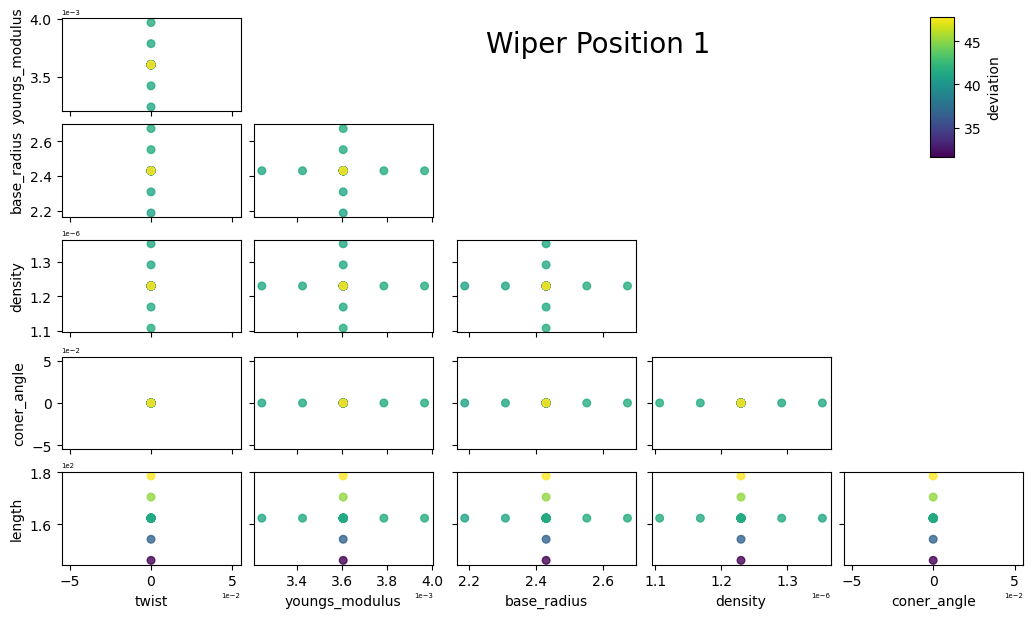

In [14]:
#| label: w1-scatter

myscatter(doe_df.drop('scenario',axis=1)[:25],1)

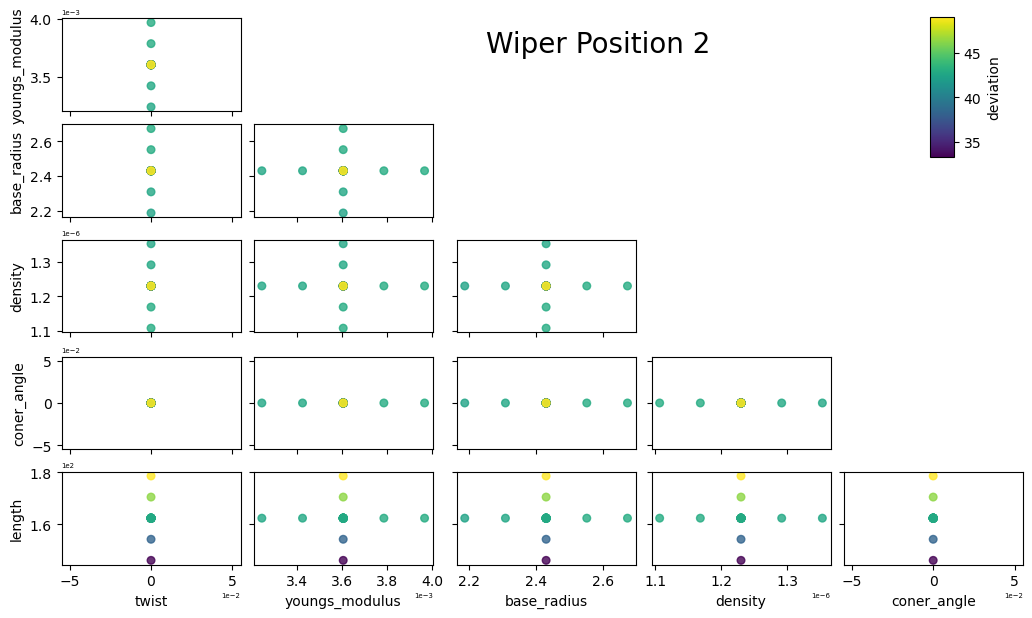

In [15]:
#| label: w2-scatter

myscatter(doe_df.drop('scenario',axis=1)[25:50],2)

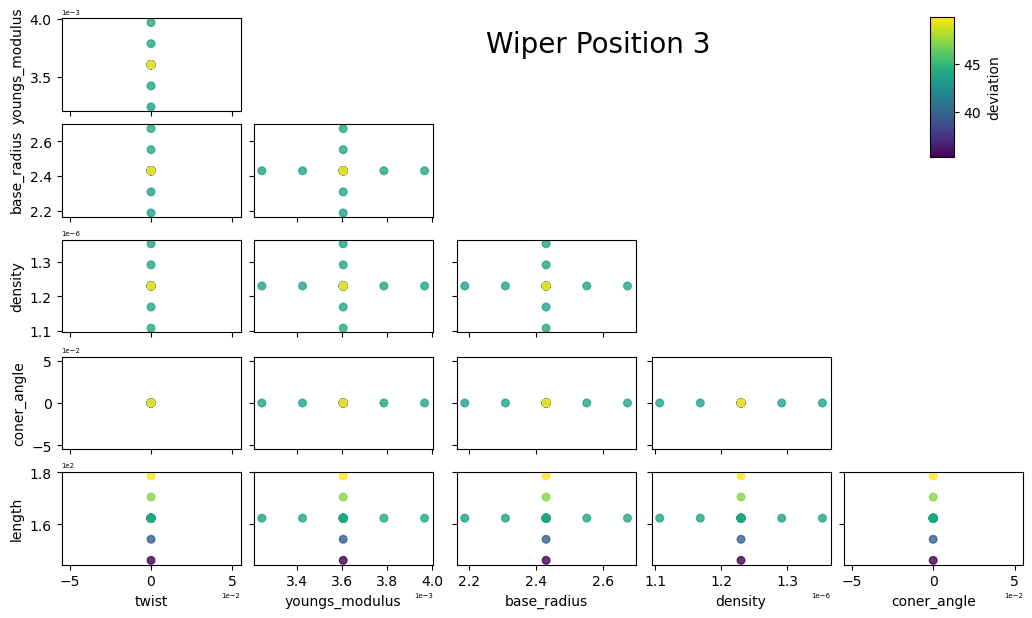

In [16]:
#| label: w3-scatter

myscatter(doe_df.drop('scenario',axis=1)[50:75],3)

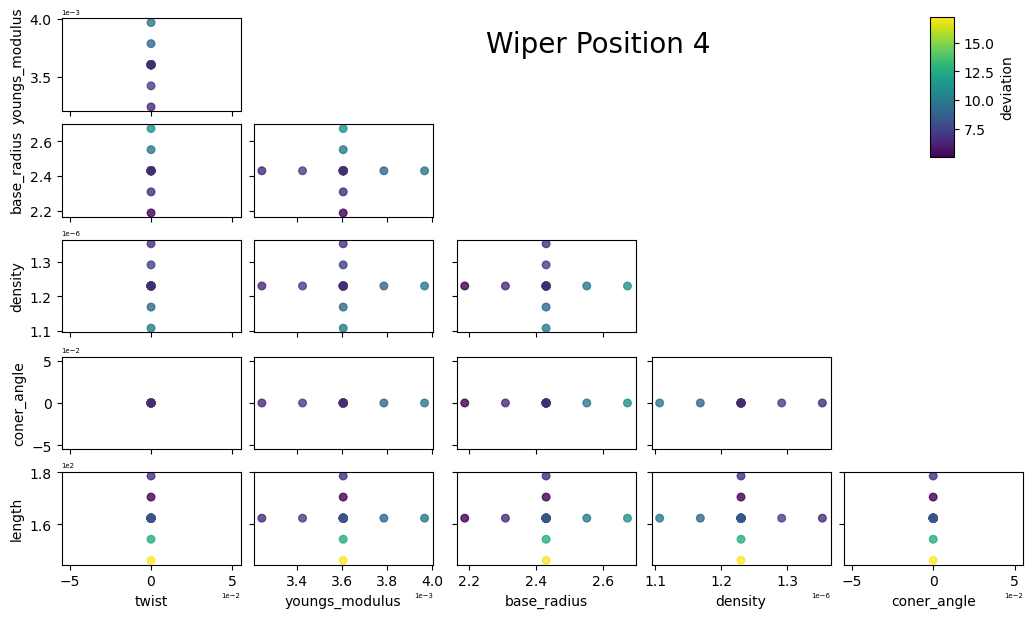

In [17]:
#| label: w4-scatter

myscatter(doe_df.drop('scenario',axis=1)[75:100],4)

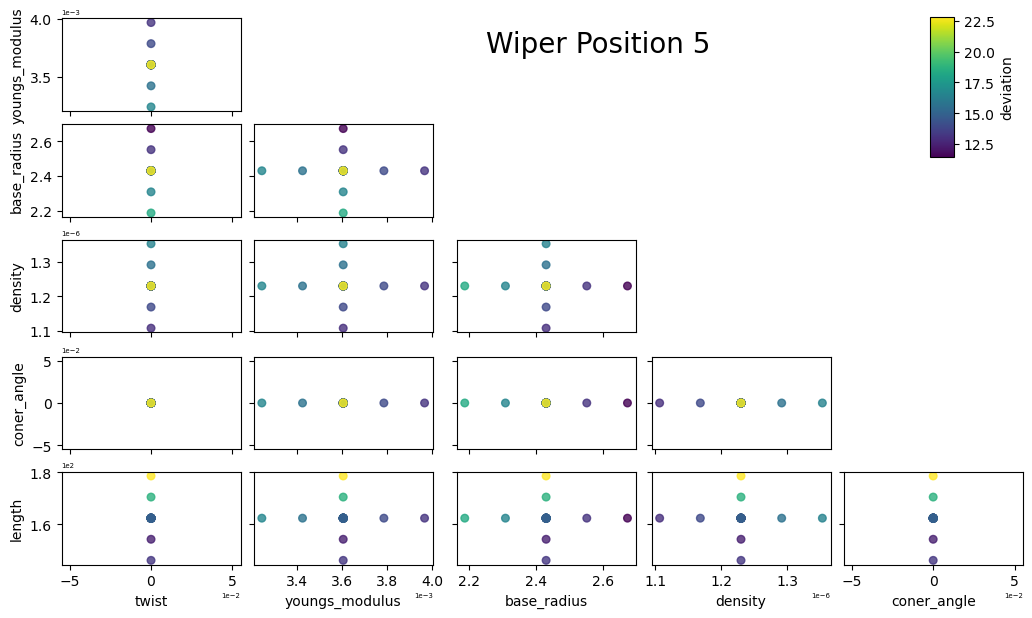

In [18]:
#| label: w5-scatter

myscatter(doe_df.drop('scenario',axis=1)[100:],5)

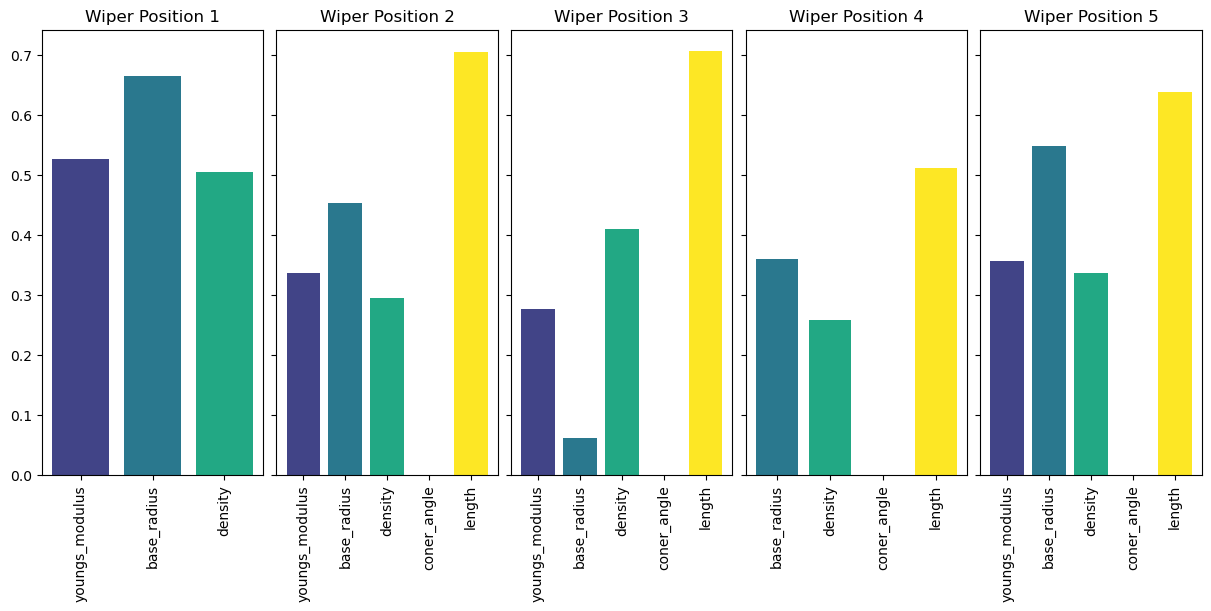

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(12,6), constrained_layout=True, sharey=True)
impdf = doe_df.drop(['case','scenario'], axis=1)
for i, ax in enumerate(axes):
    chunk = impdf.iloc[i*20:(i+1)*20]
    importance = (
        chunk.corr(method="spearman", numeric_only=True)["deviation"]
        .drop("deviation")
        .abs()
    )
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance)))
    ax.bar(importance.index, importance.values, color=colors)
    ax.set_title(f"Wiper Position {i+1}")
    ax.tick_params(axis='x',rotation=90)